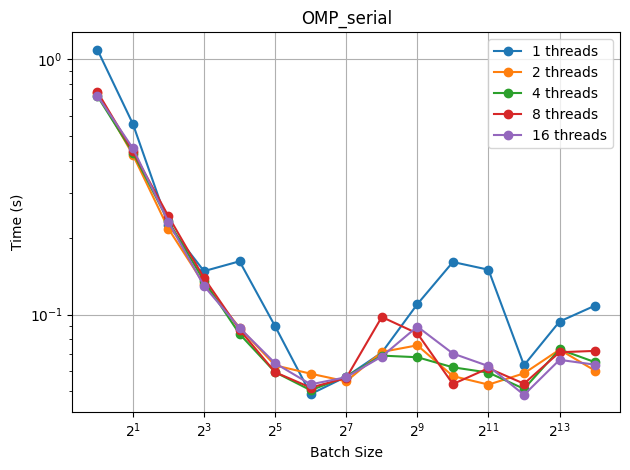

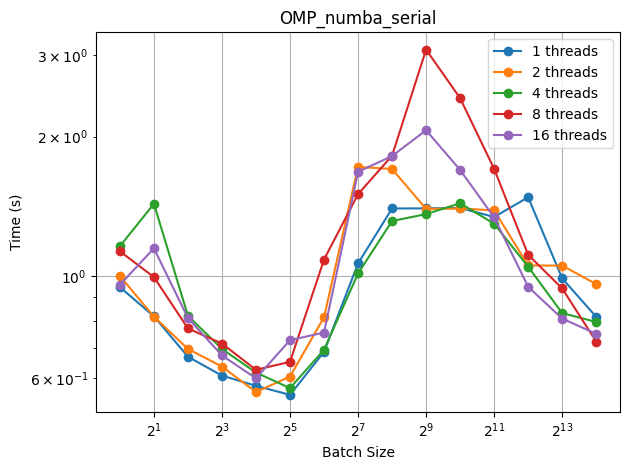

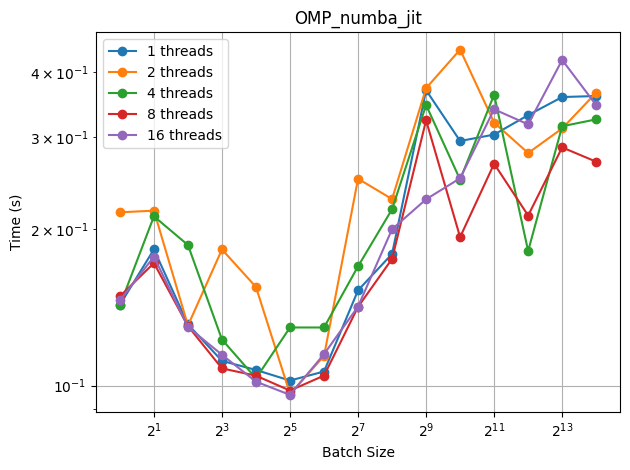

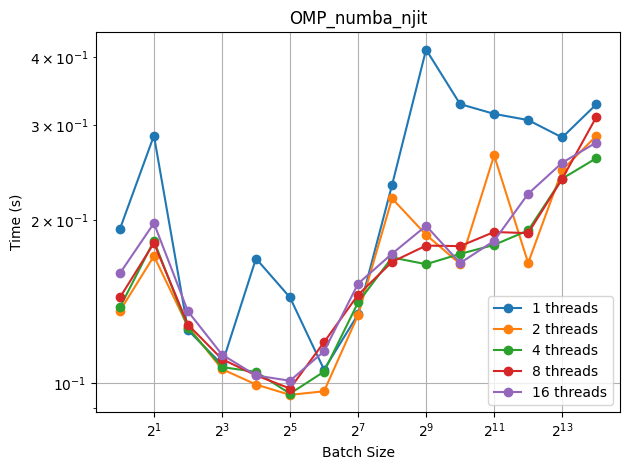

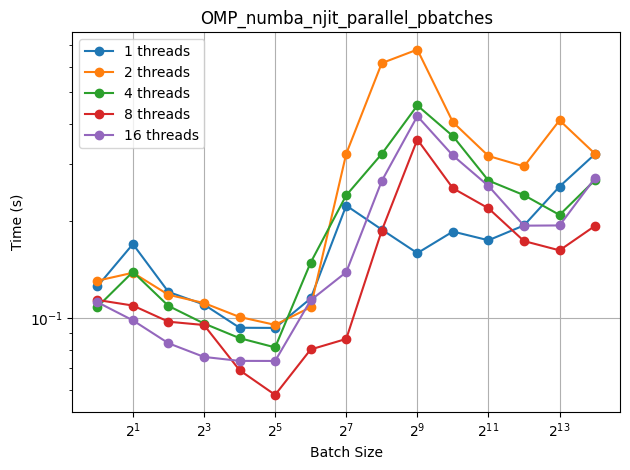

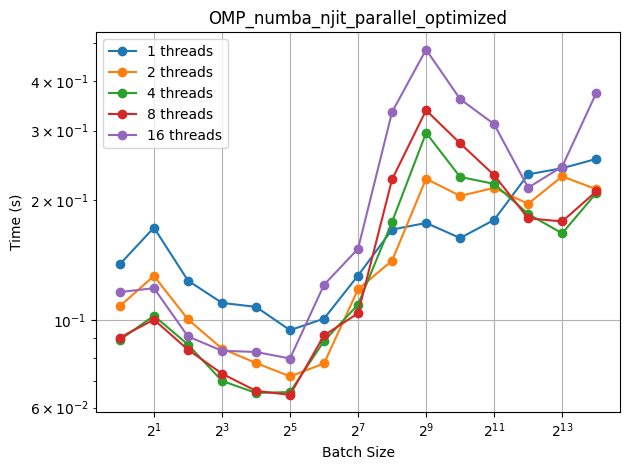

In [2]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("omp_benchmark_all.csv")

functions = df["function"].unique()

for fn in functions:
    plt.figure()
    
    subset_fn = df[df["function"] == fn]
    threads_list = sorted(subset_fn["threads"].unique())

    for t in threads_list:
        sub = subset_fn[subset_fn["threads"] == t]
        
        plt.plot(
            sub["batch_size"],
            sub["time_sec"],
            marker='o',
            label=f"{t} threads"
        )

    plt.xscale("log", base=2)
    plt.yscale("log")

    plt.xlabel("Batch Size")
    plt.ylabel("Time (s)")
    plt.title(fn)

    plt.legend()
    plt.grid(True)
    plt.tight_layout()

    plt.show()

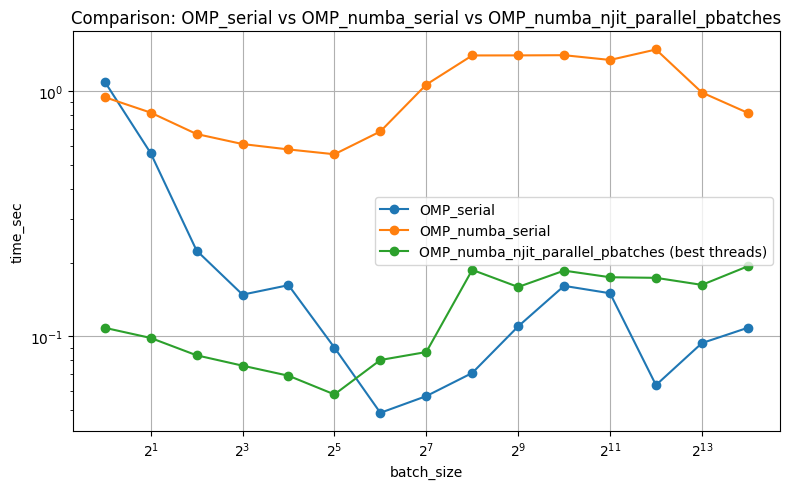

In [3]:
compare_funcs = ["OMP_serial", "OMP_numba_serial", "OMP_numba_njit_parallel_pbatches"]
sub_compare = df[df["function"].isin(compare_funcs)]

plt.figure(figsize=(8, 5))

for fn in compare_funcs:
    sub_fn = sub_compare[sub_compare["function"] == fn]

    if fn == "OMP_numba_njit_parallel_pbatches":
        # for parallel version, plot the best thread case (fastest per batch_size)
        grouped = sub_fn.groupby("batch_size")["time_sec"].min().reset_index()
        plt.plot(grouped["batch_size"], grouped["time_sec"], marker="o", label=f"{fn} (best threads)")
    else:
        # serial versions are all thread=1
        sub1 = sub_fn[sub_fn["threads"] == 1]
        plt.plot(sub1["batch_size"], sub1["time_sec"], marker="o", label=fn)

plt.xscale("log", base=2)
plt.yscale("log")
plt.xlabel("batch_size")
plt.ylabel("time_sec")
plt.title("Comparison: OMP_serial vs OMP_numba_serial vs OMP_numba_njit_parallel_pbatches")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

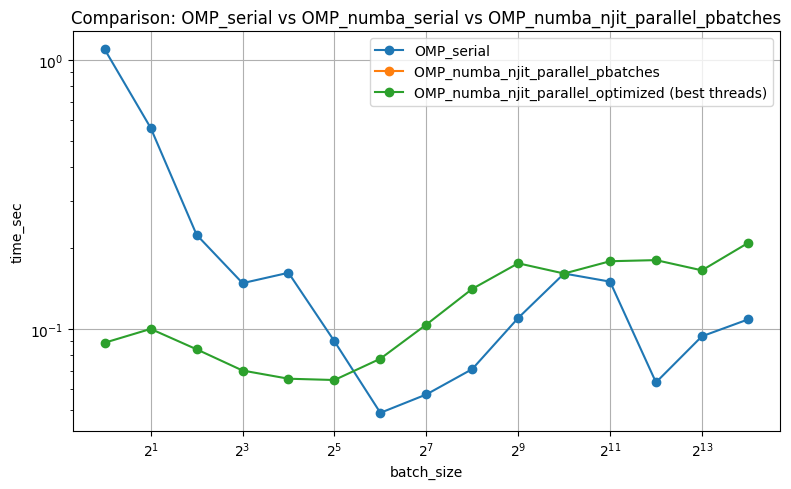

In [ ]:
compare_funcs = ["OMP_serial", "OMP_numba_njit_parallel_pbatches", "OMP_numba_njit_parallel_optimized"]
sub_compare = df[df["function"].isin(compare_funcs)]

plt.figure(figsize=(8, 5))

for fn in compare_funcs:
    sub_fn = sub_compare[sub_compare["function"] == fn]

    if fn == "OMP_numba_njit_parallel_pbatches":
        # for parallel version, plot the best thread case (fastest per batch_size)
        grouped = sub_fn.groupby("batch_size")["time_sec"].min().reset_index()
        plt.plot(grouped["batch_size"], grouped["time_sec"], marker="o", label=f"{fn} (best threads)")
    elif fn == "OMP_numba_njit_parallel_optimized":
        # for parallel version, plot the best thread case (fastest per batch_size)
        grouped = sub_fn.groupby("batch_size")["time_sec"].min().reset_index()
        plt.plot(grouped["batch_size"], grouped["time_sec"], marker="o", label=f"{fn} (best threads)")
    else:
        # serial versions are all thread=1
        sub1 = sub_fn[sub_fn["threads"] == 1]
        plt.plot(sub1["batch_size"], sub1["time_sec"], marker="o", label=fn)

plt.xscale("log", base=2)
plt.yscale("log")
plt.xlabel("batch_size")
plt.ylabel("time_sec")
plt.title("Comparison: OMP_serial vs OMP_numba_serial vs OMP_numba_njit_parallel_pbatches")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()